##Total Least Squares Fit

Saving crop_field_c.jpg to crop_field_c (8).jpg
Total Least Squares Angle (degrees): -4.997768954658446


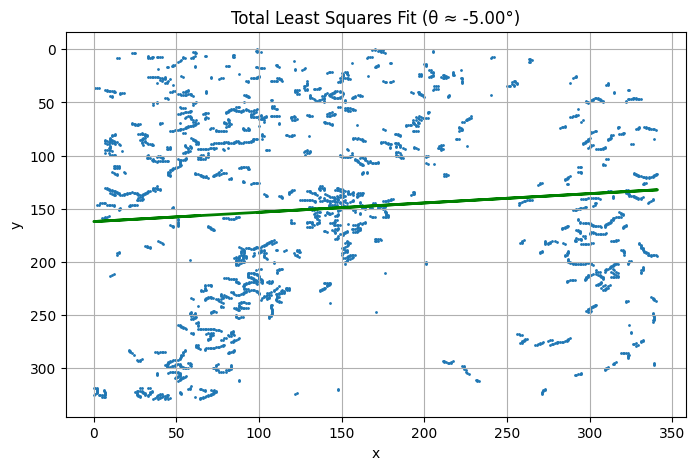

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

edges = cv2.Canny(img, 550, 690)

indices = np.where(edges != 0)
x = indices[1]   # horizontal coordinates
y = indices[0]   # vertical coordinates

# ToTal LeAst SqUaRe Fit using Singular Value Decomposition
X = x - np.mean(x)
Y = y - np.mean(y)
data = np.vstack((X, Y))
U, S, Vt = np.linalg.svd(data.T)

m_tls = Vt[0,1] / Vt[0,0]
b_tls = np.mean(y) - m_tls*np.mean(x)
theta_tls = np.degrees(np.arctan(m_tls))
print("Total Least Squares Angle (degrees):", theta_tls)

# Plots
plt.figure(figsize=(8,5))
plt.scatter(x, y, s=1)
plt.plot(x, m_tls*x + b_tls, color='green', linewidth=2)
plt.gca().invert_yaxis()
plt.title(f"Total Least Squares Fit (θ ≈ {theta_tls:.2f}°)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()